A consultation based company is planning to establish a food vendor outlet at different potential location. Your task is to build a multiclass classification model that helps a company decide whether a location is 0(not recommened),1(moderate potential) or 2(high potential)

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/food_vendor_consultation.csv"
df = pd.read_csv(url)


In [2]:
df.head()


,foot_traffic,avg_income,competitor_count,rent_cost,population_density,parking_score,visibility_score,hygiene_rating,marketing_score,vendor_category
0,699.0,81.0,3,138.4,68.9,2,2,4.1,81.7,0
1,572.0,73.9,6,100.8,93.1,6,2,4.9,55.4,1
2,730.0,60.9,4,72.9,60.1,3,6,2.4,73.8,1
3,905.0,50.3,6,148.2,61.1,2,1,2.6,63.0,0
4,553.0,70.5,9,107.1,77.2,1,6,4.6,67.3,1


In [3]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

model.add(Dense(100,activation="softmax",input_dim = X_train.shape[1]))
model.add(Dense(3))


C:\Users\Priyadarshi_Kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [8]:
history = model.fit(X_train,y_train,epochs=300,batch_size=16)


Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3000 - loss: 1.6286
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2788 - loss: 1.0986
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 9/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 10/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 11/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2800 - loss: 1.0986
Epoch 12/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [9]:
y_pred = model.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [10]:
import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)


In [11]:
y_pred_labels


array([2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 0, 0, 2, 0, 2,
       2, 1, 0, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2, 1, 0, 2, 0, 2, 1, 0, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0,
       0, 2, 0, 0, 2, 2, 1, 2, 0, 0, 2, 0, 2, 1, 0, 2, 0, 0, 0, 2, 2, 1,
       0, 0, 2, 1, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2, 1, 2, 1, 2, 0, 2, 0,
       2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2,
       1, 2, 0, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 1, 0, 2, 0, 2, 2, 2,
       2, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0,
       0, 2])

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score


In [13]:
acc_sc = accuracy_score(y_test, y_pred_labels)
print(acc_sc)


0.33


In [14]:
confusion_matrix(y_test, y_pred_labels)


array([[33,  1, 32],
       [36,  5, 26],
       [31,  8, 28]])

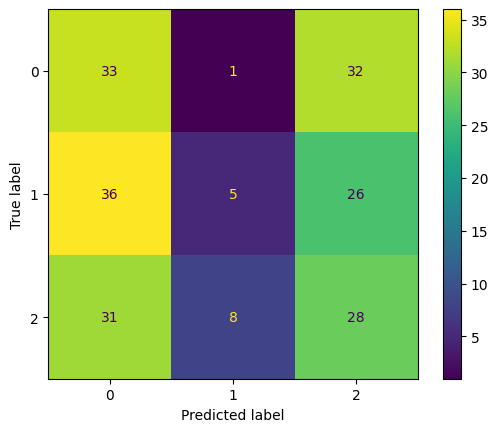

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels)
